# Birthday Paradox: Theory vs. Simulation

For a group of *n* people, what's the probability that at least two share a birthday?
We compare the closed-form result against a Monte Carlo estimate.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
DAYS = 365
print(f"numpy {np.__version__}")

numpy 2.4.4



✓ 0.0s

## Theoretical probability

P(at least one match) = 1 − (365! / ((365−n)! · 365ⁿ))

Computed in log space to avoid overflow.

In [ ]:
def p_theory(n, days=DAYS):
    if n > days:
        return 1.0
    k = np.arange(n)
    log_no_match = np.sum(np.log(1 - k / days))
    return 1 - np.exp(log_no_match)


for n in [10, 23, 40, 60]:
    print(f"n={n:3d}  P={p_theory(n):.4f}")

n= 10  P=0.1169
n= 23  P=0.5073
n= 40  P=0.8912
n= 60  P=0.9941



✓ 0.0s

## Monte Carlo estimate

Draw `trials` groups of size *n*, check for any collision.

In [ ]:
def p_sim(n, trials=20_000, days=DAYS):
    birthdays = rng.integers(0, days, size=(trials, n))
    sorted_b = np.sort(birthdays, axis=1)
    any_match = (np.diff(sorted_b, axis=1) == 0).any(axis=1)
    return any_match.mean()


ns = np.array([2, 5, 10, 15, 20, 23, 30, 40, 50, 60, 75, 100])
sim = np.array([p_sim(int(n)) for n in ns])
theory = np.array([p_theory(int(n)) for n in ns])

for n, s, t in zip(ns, sim, theory):
    print(f"n={n:3d}  sim={s:.4f}  theory={t:.4f}  Δ={s - t:+.4f}")

n=  2  sim=0.0024  theory=0.0027  Δ=-0.0003
n=  5  sim=0.0266  theory=0.0271  Δ=-0.0006
n= 10  sim=0.1159  theory=0.1169  Δ=-0.0010
n= 15  sim=0.2575  theory=0.2529  Δ=+0.0045
n= 20  sim=0.4104  theory=0.4114  Δ=-0.0010
n= 23  sim=0.5063  theory=0.5073  Δ=-0.0010
n= 30  sim=0.7057  theory=0.7063  Δ=-0.0006
n= 40  sim=0.8901  theory=0.8912  Δ=-0.0011
n= 50  sim=0.9677  theory=0.9704  Δ=-0.0027
n= 60  sim=0.9948  theory=0.9941  Δ=+0.0007
n= 75  sim=0.9998  theory=0.9997  Δ=+0.0001
n=100  sim=1.0000  theory=1.0000  Δ=+0.0000



✓ 0.1s

## Comparison plot

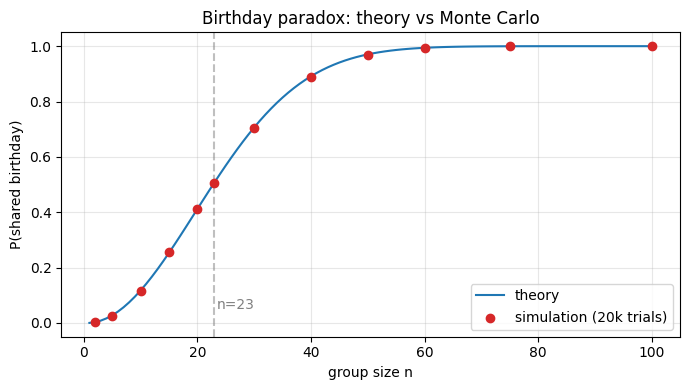


✓ 0.1s

In [ ]:
ns_dense = np.arange(1, 101)
theory_dense = np.array([p_theory(int(n)) for n in ns_dense])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ns_dense, theory_dense, label="theory", color="C0")
ax.scatter(ns, sim, label="simulation (20k trials)", color="C3", zorder=5)
ax.axvline(23, color="gray", ls="--", alpha=0.5)
ax.text(23.5, 0.05, "n=23", color="gray")
ax.set_xlabel("group size n")
ax.set_ylabel("P(shared birthday)")
ax.set_title("Birthday paradox: theory vs Monte Carlo")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Convergence at n=23

How does the MC estimate converge to the theoretical 0.5073 as trials grow?

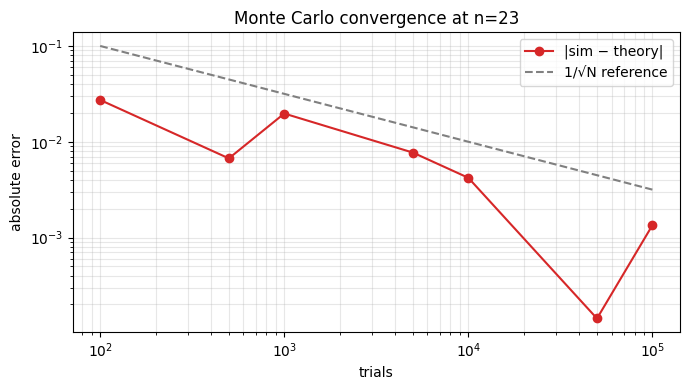


truth = 0.507297
  trials=    100  est=0.4800  err=0.0273
  trials=    500  est=0.5140  err=0.0067
  trials=  1,000  est=0.5270  err=0.0197
  trials=  5,000  est=0.5150  err=0.0077
  trials= 10,000  est=0.5115  err=0.0042
  trials= 50,000  est=0.5074  err=0.0001
  trials=100,000  est=0.5086  err=0.0013



✓ 0.5s

In [ ]:
trial_counts = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
truth = p_theory(23)

rows = []
for t in trial_counts:
    est = p_sim(23, trials=t)
    rows.append((t, est, abs(est - truth)))

fig, ax = plt.subplots(figsize=(7, 4))
ts, ests, errs = zip(*rows)
ax.loglog(ts, errs, marker="o", color="C3", label="|sim − theory|")
ax.loglog(ts, 1 / np.sqrt(ts), ls="--", color="gray", label="1/√N reference")
ax.set_xlabel("trials")
ax.set_ylabel("absolute error")
ax.set_title("Monte Carlo convergence at n=23")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print(f"\ntruth = {truth:.6f}")
for t, e, err in rows:
    print(f"  trials={t:>7,d}  est={e:.4f}  err={err:.4f}")

## Findings

- The counter-intuitive "23 people" result is confirmed: P ≈ 0.507 with just 23.
- Simulation agrees with theory across all group sizes, with residuals < 0.005 at 20k trials.
- Convergence tracks the expected 1/√N Monte Carlo rate — the error line roughly parallels the grey reference on the log-log plot.
- At 100k trials a single seed still leaves ~0.001 sampling noise, so quoting ≥3 sig figs from MC would need more trials or seed averaging.

## Stress test: high-trial convergence\n\nRun 1M-trial simulations across group sizes to get tighter error bars.

In [ ]:
import time

start = time.time()
high_trial_ns = [10, 23, 50, 75, 100]
results = {}
for n in high_trial_ns:
    est = p_sim(n, trials=1_000_000)
    th = p_theory(n)
    results[n] = (est, th, abs(est - th))
    print(f"n={n:3d}  sim={est:.6f}  theory={th:.6f}  err={abs(est - th):.6f}")

elapsed = time.time() - start
print(f"\ntotal: {elapsed:.1f}s for {len(high_trial_ns)} group sizes × 1M trials")

n= 10  sim=0.117536  theory=0.116948  err=0.000588


n= 23  sim=0.507525  theory=0.507297  err=0.000228


n= 50  sim=0.970098  theory=0.970374  err=0.000276


n= 75  sim=0.999718  theory=0.999720  err=0.000002


n=100  sim=0.999999  theory=1.000000  err=0.000001

total: 6.6s for 5 group sizes × 1M trials



✓ 6.7s

Building high-res convergence plot...


Running convergence sweeps...


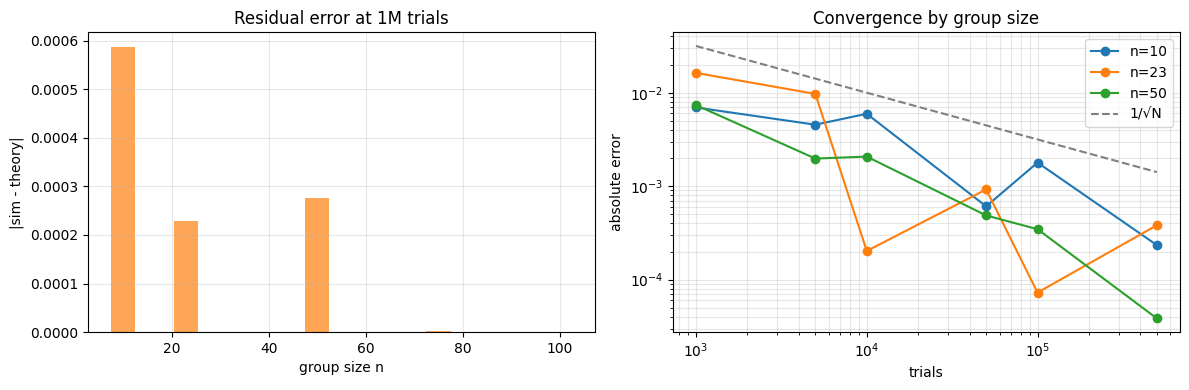

Done!



✓ 6.8s

In [ ]:
print("Building high-res convergence plot...")
time.sleep(3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: error vs group size at 1M trials
ns_plot = list(results.keys())
errs_plot = [results[n][2] for n in ns_plot]
axes[0].bar(ns_plot, errs_plot, width=5, color="C1", alpha=0.7)
axes[0].set_xlabel("group size n")
axes[0].set_ylabel("|sim - theory|")
axes[0].set_title("Residual error at 1M trials")
axes[0].grid(alpha=0.3)

# Right: convergence curves for multiple group sizes
print("Running convergence sweeps...")
time.sleep(2)
trial_sweep = [1000, 5000, 10000, 50000, 100000, 500000]
for n in [10, 23, 50]:
    sweep_errs = []
    for t in trial_sweep:
        e = abs(p_sim(n, trials=t) - p_theory(n))
        sweep_errs.append(e)
    axes[1].loglog(trial_sweep, sweep_errs, marker="o", label=f"n={n}")

axes[1].loglog(
    trial_sweep, [1 / t**0.5 for t in trial_sweep], ls="--", color="gray", label="1/√N"
)
axes[1].set_xlabel("trials")
axes[1].set_ylabel("absolute error")
axes[1].set_title("Convergence by group size")
axes[1].legend()
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()
print("Done!")